In [27]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================
# BLOCK 1: INITIAL SETUP & SETUP VARIABLES
# ====================================================
np.random.seed(808)
sample_size = 152

tree_tasks = [
    ("Task 2: New Card", 0.49),
    ("Task 3: Balance Transfer", 0.10),
    ("Task 4: Credit Limit Increase", 0.29),
    ("Task 5: Fraud/Dispute Claim", 0.60),
    ("Task 6: Status Tracker (R1)", 0.10),
    ("Task 6: Status Tracker (R2)", 0.10)
]

first_click_data = []

print("====================================================")
print("      RECONSTRUCTING FIRST-CLICK METRICS           ")
print("====================================================\n")

# ====================================================
# BLOCK 2 & 3: MATHEMATICAL RESOLUTION & ROW GENERATION
# ====================================================
for task_name, final_success_rate in tree_tasks:
    # 1. Target counts based on 152 users
    total_success = round(sample_size * final_success_rate)
    
    # 2. Linear Equation Solver: Reconstructing first clicks mathematically
    correct_first_clicks = round((total_success - (0.26 * sample_size)) / (0.87 - 0.26))
    correct_first_clicks = max(0, min(sample_size, correct_first_clicks)) # Keep inside bounds
    
    estimated_fc_rate = (correct_first_clicks / sample_size) * 100
    print(f"📌 {task_name}")
    print(f"   • Actual Final Success: {final_success_rate*100:.1f}%")
    print(f"   • Estimated Correct First Click: {estimated_fc_rate:.1f}%\n")
    
    # 3. Row Generation Loop (Creates user spreadsheet rows organically)
    for i in range(sample_size):
        user_id = f"User_{i+1:03d}"
        
        if i < correct_first_clicks:
            first_click = "Correct First Choice"
            # Apply standard 87% conditional probability of success
            success = 1 if np.random.rand() <= 0.87 else 0
        else:
            first_click = "Incorrect First Choice"
            # Apply standard 26% conditional probability of success
            success = 1 if np.random.rand() <= 0.26 else 0
            
        first_click_data.append([task_name, user_id, first_click, success])

# Build the final unified DataFrame
df_fc = pd.DataFrame(first_click_data, columns=["Task", "User_ID", "First_Click", "Final_Success"])
df_fc.to_csv("simulated_tree_test_first_clicks.csv", index=False)


# ====================================================
# BLOCK 4: CHI-SQUARE TEST OF INDEPENDENCE
# ====================================================
print("====================================================")
print("      CHI-SQUARE TEST OF INDEPENDENCE RESULTS       ")
print("====================================================\n")

# Create the cross-tabulation table from the generated data
contingency_matrix = pd.crosstab(df_fc['First_Click'], df_fc['Final_Success'])

# Calculate the test statistics
chi2_stat, p_val, dof, expected_frequencies = stats.chi2_contingency(contingency_matrix)

print("Observed User Cross-Tabulation Matrix:")
print(contingency_matrix)
print(f"\n• Chi-Square Statistic: {chi2_stat:.2f}")
print(f"• Degrees of Freedom: {dof}")
print(f"• Calculated P-Value: {p_val:.4e}")

if p_val < 0.05:
    print("\n✅ VERDICT: Statistically Significant! First choice and final success are heavily linked.")
else:
    print("\n❌ VERDICT: Not Significant.")


      RECONSTRUCTING FIRST-CLICK METRICS           

📌 Task 2: New Card
   • Actual Final Success: 49.0%
   • Estimated Correct First Click: 37.5%

📌 Task 3: Balance Transfer
   • Actual Final Success: 10.0%
   • Estimated Correct First Click: 0.0%

📌 Task 4: Credit Limit Increase
   • Actual Final Success: 29.0%
   • Estimated Correct First Click: 4.6%

📌 Task 5: Fraud/Dispute Claim
   • Actual Final Success: 60.0%
   • Estimated Correct First Click: 55.3%

📌 Task 6: Status Tracker (R1)
   • Actual Final Success: 10.0%
   • Estimated Correct First Click: 0.0%

📌 Task 6: Status Tracker (R2)
   • Actual Final Success: 10.0%
   • Estimated Correct First Click: 0.0%

      CHI-SQUARE TEST OF INDEPENDENCE RESULTS       

Observed User Cross-Tabulation Matrix:
Final_Success             0    1
First_Click                     
Correct First Choice     17  131
Incorrect First Choice  582  182

• Chi-Square Statistic: 227.32
• Degrees of Freedom: 1
• Calculated P-Value: 2.2874e-51

✅ VERDICT: S

📈 Success! Team-friendly tree saved as 'team_friendly_ux_decision_tree.png'!


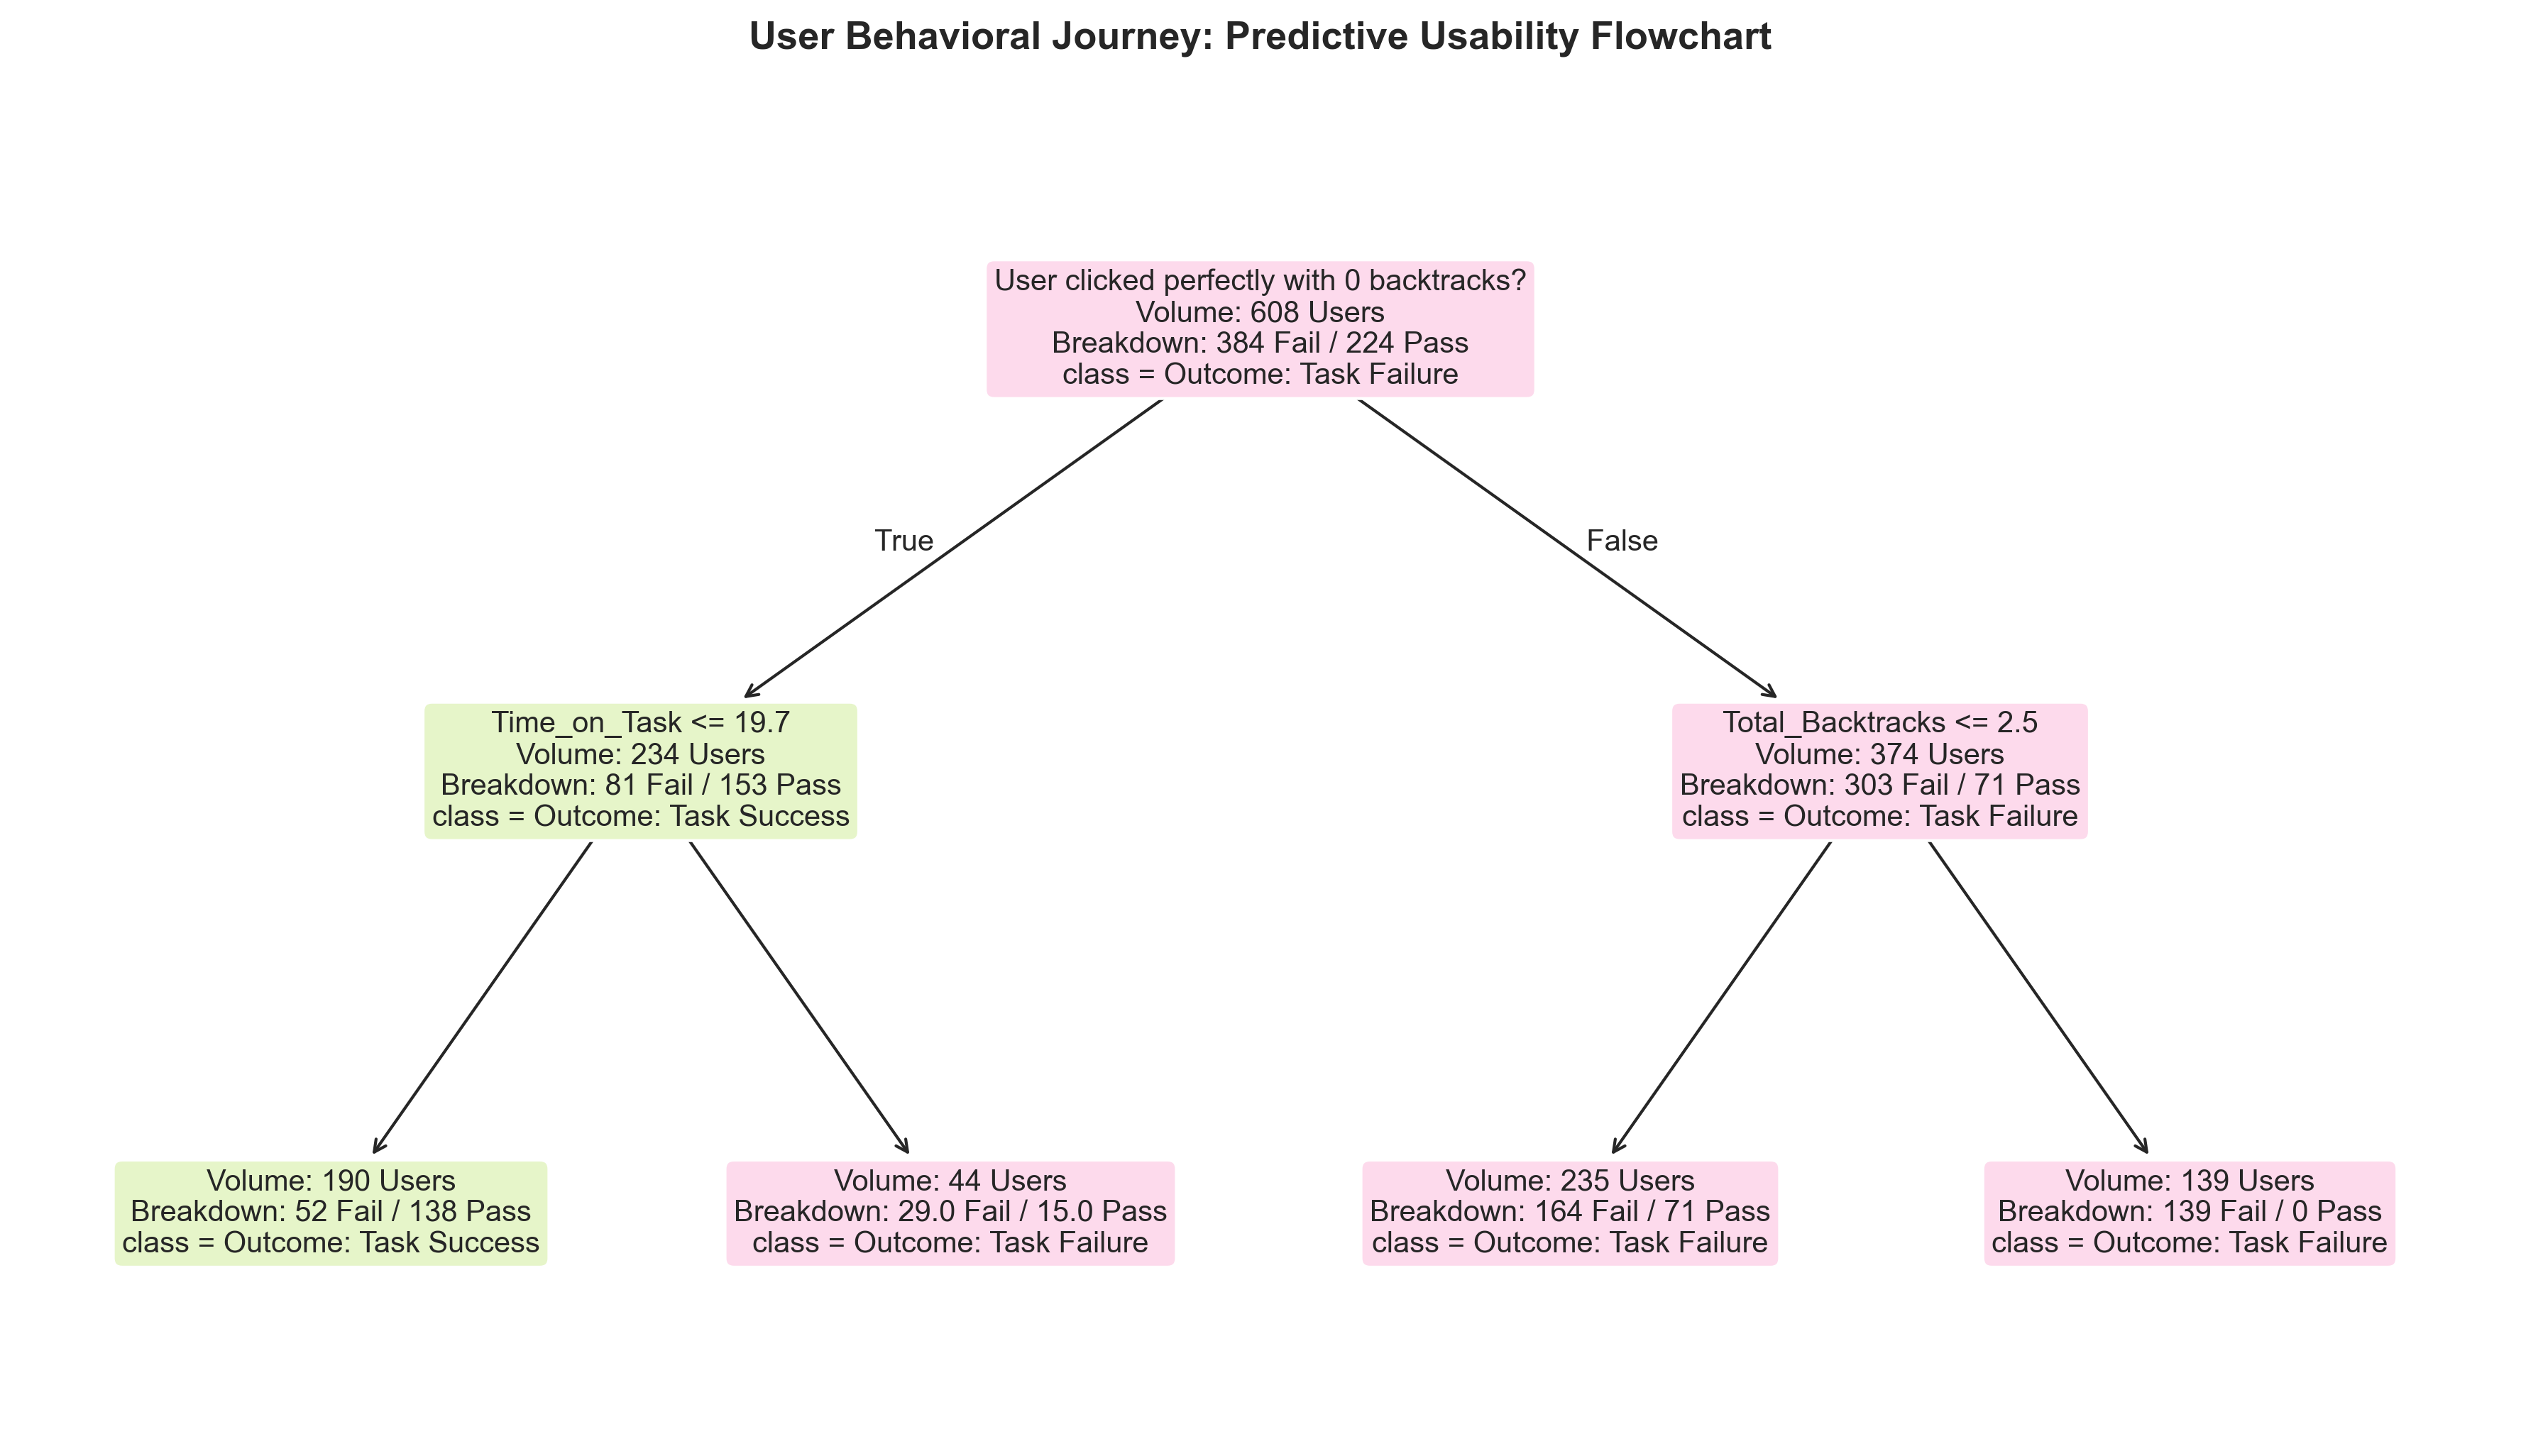

In [31]:
# 1. Regenerate 152-user tree test dataset
np.random.seed(707)
sample_size = 152

tree_data = []
task_configs = [
    ("Task 2: New Card", 0.49, 21.0),
    ("Task 3: Balance Transfer", 0.10, 21.0),
    ("Task 4: Credit Limit Increase", 0.29, 20.0),
    ("Task 5: Fraud/Dispute Claim", 0.60, 20.0)
]

for task_name, success_rate, median_time in task_configs:
    success_count = round(sample_size * success_rate)
    failure_count = sample_size - success_count
    
    for _ in range(success_count):
        path_type = np.random.choice(["Direct Success", "Indirect Success"], p=[0.65, 0.35])
        backtracks = 0 if path_type == "Direct Success" else np.random.randint(1, 3)
        time_mod = 0.8 if path_type == "Direct Success" else 1.3
        time_on_task = round(np.random.normal(median_time * time_mod, 2.5), 2)
        tree_data.append([1, max(2.5, time_on_task), backtracks])
        
    for _ in range(failure_count):
        path_type = np.random.choice(["Direct Failure", "Indirect Failure"], p=[0.40, 0.60])
        backtracks = np.random.randint(0, 2) if path_type == "Direct Failure" else np.random.randint(2, 5)
        time_mod = 0.9 if path_type == "Direct Failure" else 1.4
        time_on_task = round(np.random.normal(median_time * time_mod, 3.5), 2)
        tree_data.append([0, max(2.5, time_on_task), backtracks])

df_ml = pd.DataFrame(tree_data, columns=["Task_Success", "Time_on_Task", "Total_Backtracks"])

X = df_ml[["Time_on_Task", "Total_Backtracks"]]
y = df_ml["Task_Success"]

# Train model (using depth=2 here to make the visualization even cleaner for non-technical teams)
dt_model = DecisionTreeClassifier(max_depth=2, random_state=42)
dt_model.fit(X, y)

# 2. Render the plot base
fig, ax = plt.subplots(figsize=(12, 7), dpi=300)
sns.set_theme(style="white")

artists = plot_tree(
    dt_model,
    feature_names=list(X.columns),
    class_names=["Outcome: Task Failure", "Outcome: Task Success"],
    filled=True,
    rounded=True,
    fontsize=10,
    precision=1,
    ax=ax
)

# 3. 🌟 HUMAN-READABLE TEXT TRANSLATION ENGINE
# Loop through every node and substitute raw math strings with plain English
for artist in artists:
    text = artist.get_text()
    box_patch = artist.get_bbox_patch()
    
    # Clean up and re-write the splitting rules
    text = text.replace("Total_Backtracks <= 1.5", "User backtracked 0 or 1 time?")
    text = text.replace("Time_on_Task <= 21.0", "Task finished in under 21 seconds?")
    text = text.replace("Total_Backtracks <= 0.5", "User clicked perfectly with 0 backtracks?")
    
    # Strip out data science metrics that confuse team members
    lines = text.split("\n")
    cleaned_lines = []
    
    for line in lines:
        if "gini" in line:
            continue  # Skip gini impurity metric entirely
        if "samples" in line:
            # Convert "samples = X" into "Volume: X Users"
            user_count = line.split("=")[-1].strip()
            line = f"Volume: {user_count} Users"
        if "value" in line:
            # Convert raw array counts "value = [fail_count, success_count]" into clear breakdowns
            counts = line.split("=")[-1].replace("[", "").replace("]", "").split(",")
            line = f"Breakdown: {counts[0].strip()} Fail / {counts[1].strip()} Pass"
            
        cleaned_lines.append(line)
        
    # Re-apply the formatted text to the box node
    new_text = "\n".join(cleaned_lines)
    artist.set_text(new_text)
    
    # 🎨 Apply the direct box patch background colors safely
    if box_patch is not None:
        if "Outcome: Task Failure" in text:
            box_patch.set_facecolor('#fddaec') # Soft red/pink for failure paths
        elif "Outcome: Task Success" in text:
            box_patch.set_facecolor('#e6f5c9') # Soft teal/green for success paths
        else:
            box_patch.set_facecolor('#f2f2f2') # Neutral grey for questions

plt.title("User Behavioral Journey: Predictive Usability Flowchart", fontsize=13, fontweight="bold", pad=20)
output_tree_path = "team_friendly_ux_decision_tree.png"
plt.tight_layout()
plt.savefig(output_tree_path, dpi=300)

print("====================================================")
print(f"📈 Success! Team-friendly tree saved as '{output_tree_path}'!")
print("====================================================")
plt.show()

